In [12]:
import torch
from torchvision import datasets, transforms
import helper
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

<Axes: >

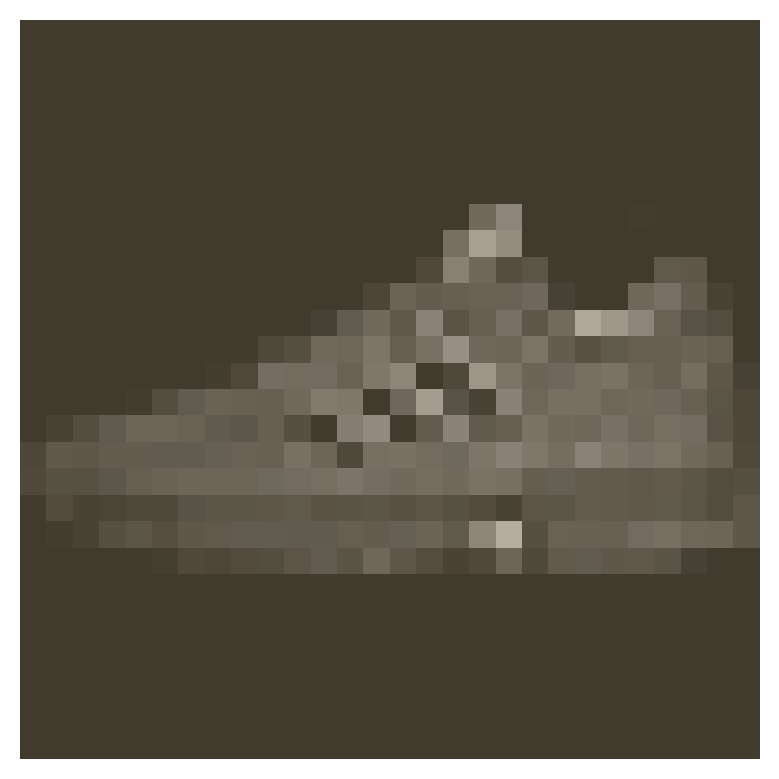

In [20]:
image, label = next(iter(trainloader))
helper.imshow(image[0,:])

In [21]:
from torch import nn,optim
import torch.nn.functional as F
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.fc4 = nn.Linear(10, 10)  # Additional layer for more complexity

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Flatten the input
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)  # Use log_softmax for numerical stability
        return x

In [22]:
model = Classifier()
criterion = nn.NLLLoss()  # Negative Log Likelihood Loss
optimizer = optim.Adam(model.parameters(), lr=0.003)  # Using Adam optimizer

In [23]:
epochs = 5
for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()  # Zero the gradients
        log_ps = model(images)  # Forward pass
        loss = criterion(log_ps, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        running_loss += loss.item()  # Accumulate loss

    print(f"Epoch {e+1}/{epochs} - Loss: {running_loss/len(trainloader)}")

Epoch 1/5 - Loss: 0.5547042857768185
Epoch 2/5 - Loss: 0.39276023020844725
Epoch 3/5 - Loss: 0.35564981007785684
Epoch 4/5 - Loss: 0.3295147475133191
Epoch 5/5 - Loss: 0.3126479934082865


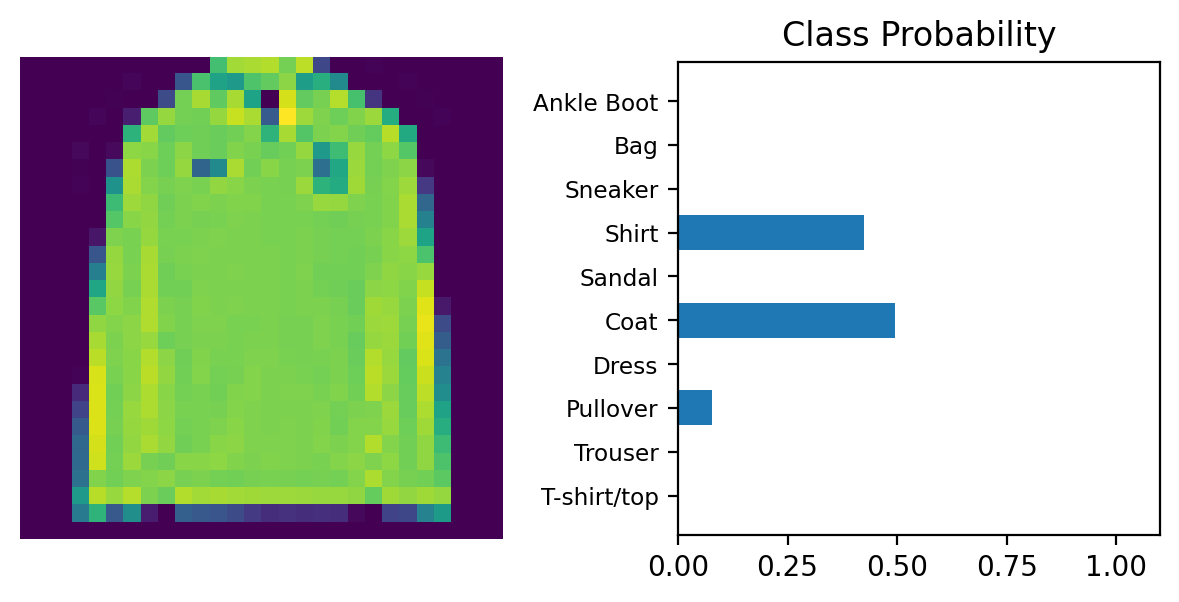

In [24]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import helper

# Test out your network!

dataiter = iter(testloader)
images, labels = next(dataiter)
img = images[1]

# TODO: Calculate the class probabilities (softmax) for img
ps = torch.exp(model(img))

# Plot the image and probabilities
helper.view_classify(img, ps, version='Fashion')